In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") 

In [2]:
url = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

In [3]:
url.shape

(235795, 56)

In [4]:
url.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [28]:
url.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  float64
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  float64
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [6]:
url.describe().T

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6.097000e+03
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,1.100000e+02
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,1.000000e+02
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000e+00
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,5.229071e-01
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,9.082366e-02
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000e+00


In [7]:
url.rename(
    columns={
        "NoOfDegitsInURL": "NoOfDigitsInURL",
        "DegitRatioInURL": "DigitRatioInURL",
        "SpacialCharRatioInURL": "SpecialCharRatioInURL"
    },
    inplace=True  
)

In [8]:
url.isnull().sum()

FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDigitsInURL               0
DigitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpecialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitle

In [1]:
num_feats = [col for col in url.select_dtypes(exclude='object').columns if url[col].nunique() > 2]
num_feats.sort()
num_feats

NameError: name 'url' is not defined

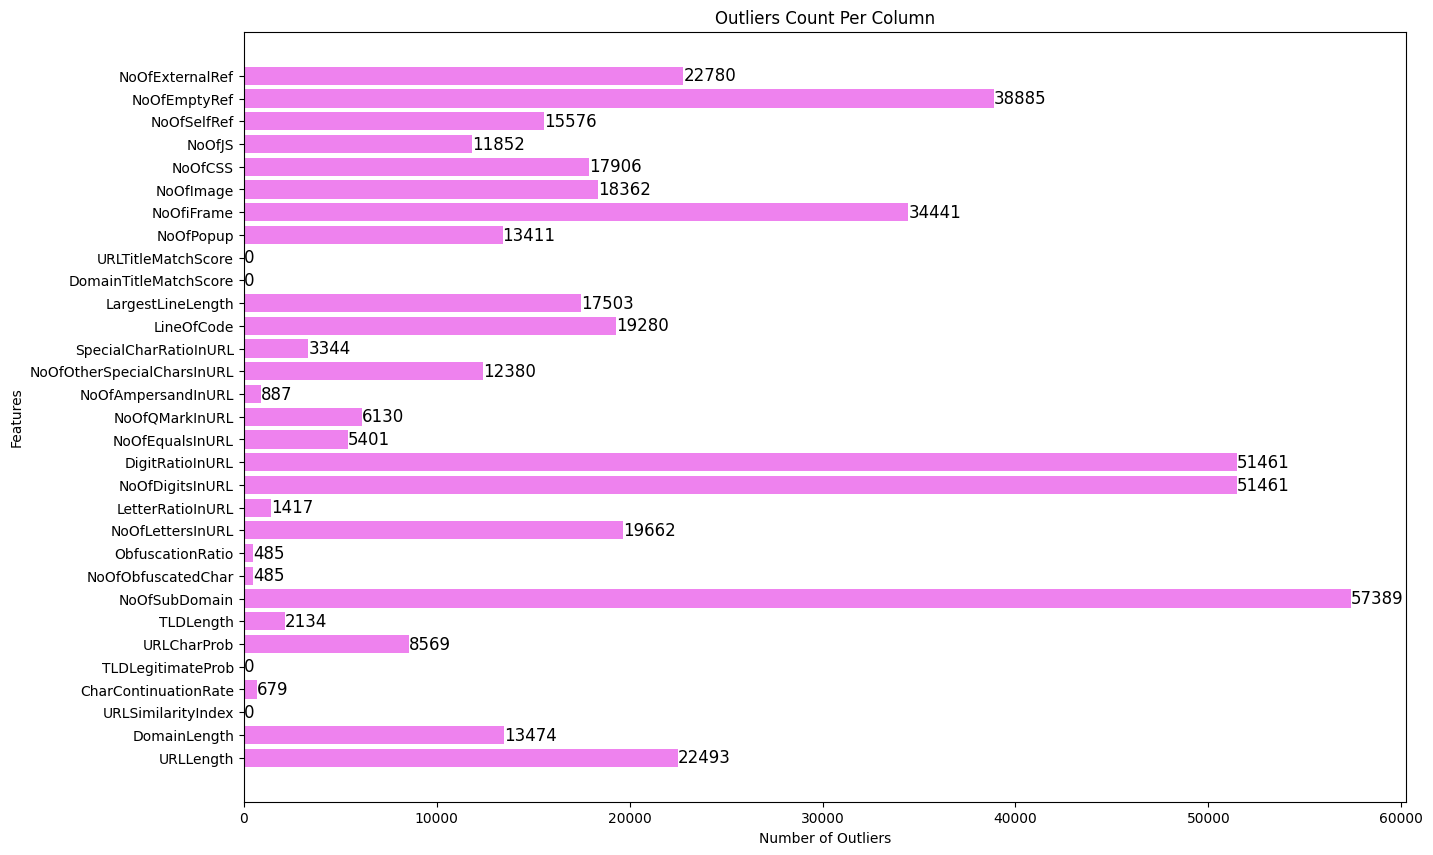

In [10]:
outlier_counts = {}

for col in num_feats: 
    Q1 = url[col].quantile(0.25) 
    Q3 = url[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_counts[col] = ((url[col] < lower_bound) | (url[col] > upper_bound)).sum()

cols = list(outlier_counts.keys())
counts = list(outlier_counts.values())

plt.figure(figsize=(15, 10))
bars = plt.barh(y=cols, width=counts, color='violet')  
plt.xlabel('Number of Outliers')
plt.ylabel('Features')
plt.title('Outliers Count Per Column')
for bar, count in zip(bars, counts):
    plt.text(bar.get_width() + 6, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=12)
plt.show()

In [11]:
def cap_outliers(df, dist_feats, threshold):
    capped_df = df.copy()
    
    for col in dist_feats:
        Q1 = capped_df[col].quantile(0.25)
        Q3 = capped_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        capped_df[col] = capped_df[col].clip(lower=lower_bound, upper=upper_bound)
    return capped_df

In [12]:
url = cap_outliers(url, num_feats, 1.5)

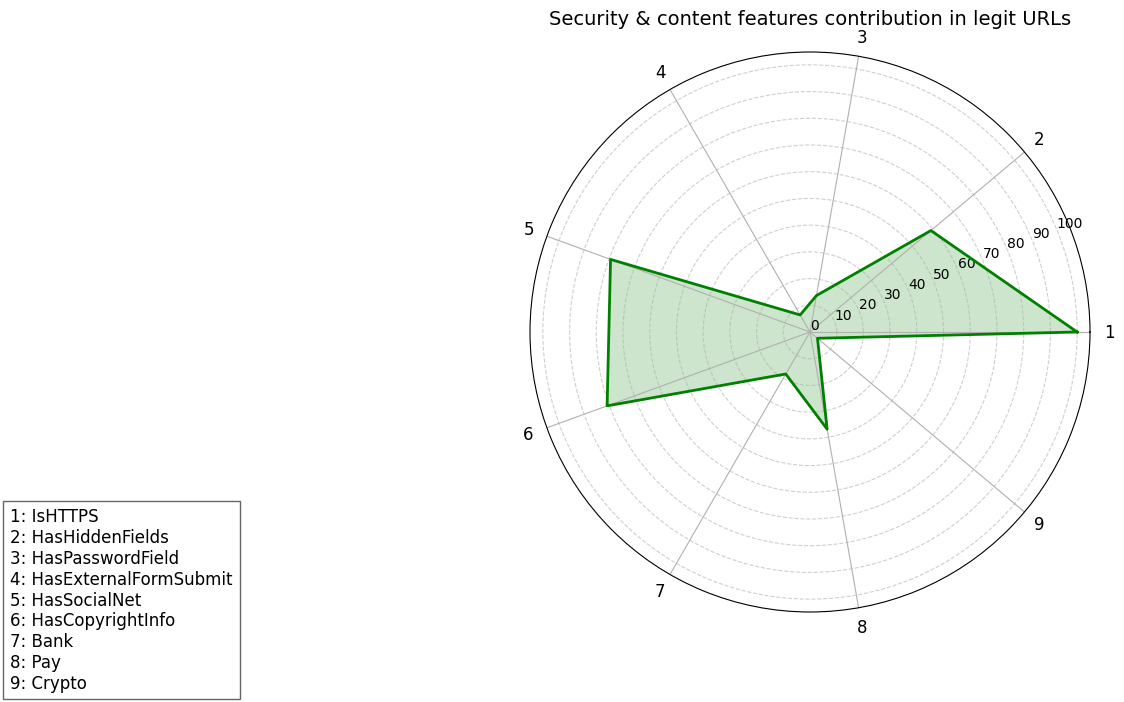

In [17]:
legit_urls = url[url["label"] == 1]

metrics_legit = {
    "IsHTTPS": legit_urls["IsHTTPS"].mean() * 100,
    "HasHiddenFields": legit_urls["HasHiddenFields"].mean() * 100,
    "HasPasswordField": legit_urls["HasPasswordField"].mean() * 100,
    "HasExternalFormSubmit": legit_urls["HasExternalFormSubmit"].mean() * 100,
    "HasSocialNet": legit_urls["HasSocialNet"].mean() * 100,
    "HasCopyrightInfo": legit_urls["HasCopyrightInfo"].mean() * 100,
    "Bank": legit_urls["Bank"].mean() * 100,
    "Pay": legit_urls["Pay"].mean() * 100,
    "Crypto": legit_urls["Crypto"].mean() * 100
}

feature_mapping = {i+1: feature for i, feature in enumerate(metrics_legit.keys())}
categories = list(feature_mapping.keys()) 
values_legit = list(metrics_legit.values())
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

values_legit += values_legit[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(20, 8), subplot_kw=dict(polar=True))
ax.plot(angles, values_legit, linewidth=2, linestyle='solid', color="green", label="Legitimate URLs (label=1)")
ax.fill(angles, values_legit, alpha=0.2, color="green")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_yticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.set_yticklabels(["0", "10", "20", "30", "40", "50", "60", "70","80", "90", "100"], fontsize=10)

ax.yaxis.grid(True, linestyle="--", alpha=0.6)
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)
plt.title("Security & content features contribution in legit URLs", fontsize=14, pad=20)
legend_text = "\n".join([f"{k}: {v}" for k, v in feature_mapping.items()])
plt.figtext(0.1, 0.05, legend_text, fontsize=12, va="bottom", ha="left", bbox={"facecolor": "white", "alpha": 0.6, "pad": 5})
plt.show()

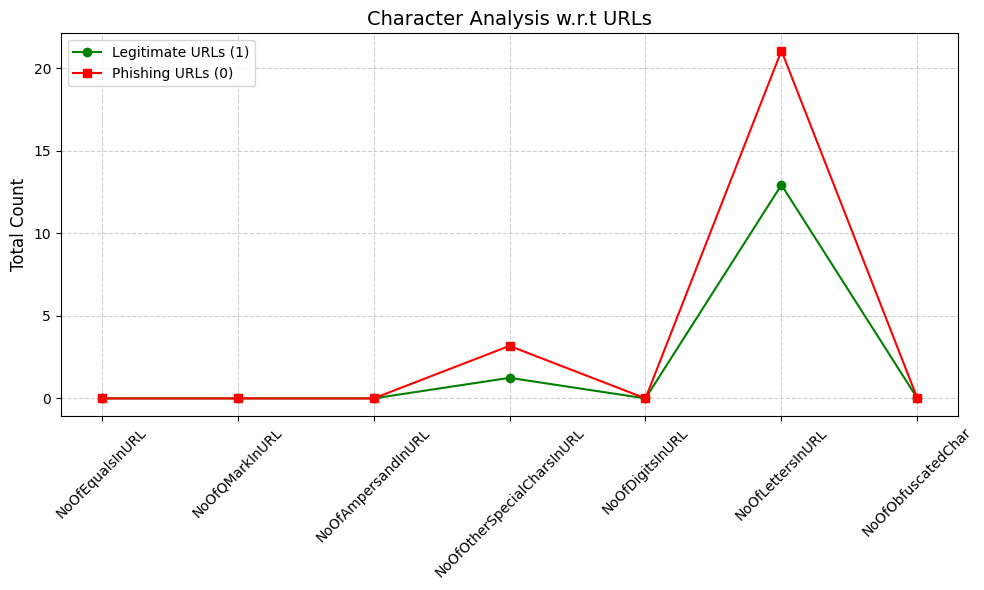

In [24]:
features = [
    "NoOfEqualsInURL", "NoOfQMarkInURL", "NoOfAmpersandInURL", "NoOfOtherSpecialCharsInURL", "NoOfDigitsInURL", "NoOfLettersInURL", "NoOfObfuscatedChar"
]

legit_counts = url[url["label"] == 1][features].mean() 
phish_counts = url[url["label"] == 0][features].mean()  
x = np.arange(len(features))

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x, legit_counts, marker='o', linestyle='-', color='green', label="Legitimate URLs (1)")
ax.plot(x, phish_counts, marker='s', linestyle='-', color='red', label="Phishing URLs (0)")
ax.set_ylabel("Total Count", fontsize=12)
ax.set_title("Character Analysis w.r.t URLs", fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, fontsize=10)  

ax.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


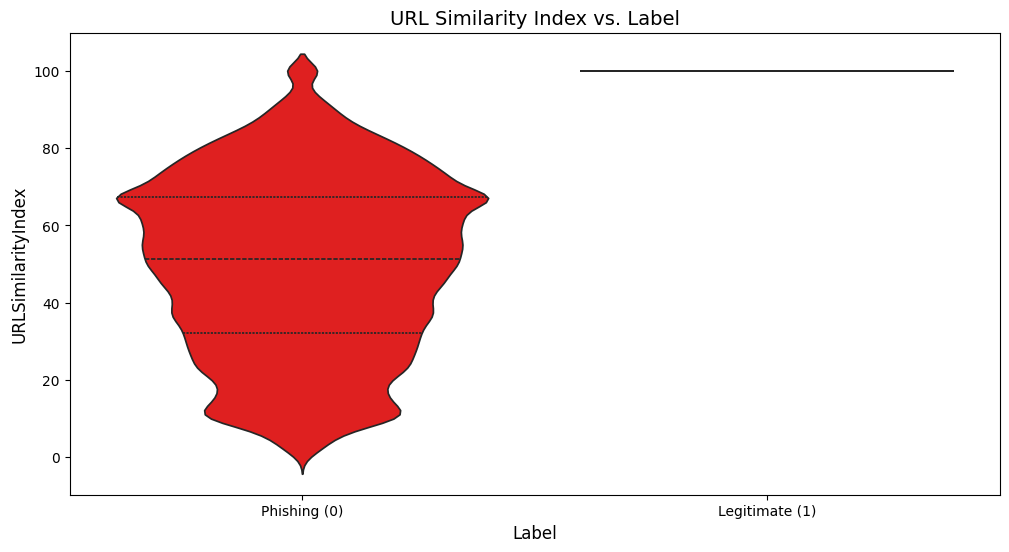

In [26]:
plt.figure(figsize=(12, 6))
sns.violinplot(x=url["label"], y=url["URLSimilarityIndex"], palette=["red", "green"], inner="quartile")
plt.xticks([0, 1], ["Phishing (0)", "Legitimate (1)"])
plt.xlabel("Label", fontsize=12)
plt.ylabel("URLSimilarityIndex", fontsize=12)
plt.title("URL Similarity Index vs. Label", fontsize=14)
plt.show()